# Independent Components Analysis (CS229) — Practical Implementation

## 1. Introduction

This notebook is the **practical companion** to the CS229 notes on
**Independent Components Analysis (ICA)**: the cocktail-party problem,
ICA's ambiguities, densities under linear transformations, and the
Bell-Sejnowski maximum-likelihood ICA algorithm.

>  **Important dataset mismatch — read this first:** `mall_customers.csv`
> (200 customers: `Age`, `Annual Income (k$)`, `Spending Score (1-100)`) is
> **not** a cocktail-party-style dataset. ICA's whole motivating structure
> is $x=As$: a fixed number of **independent sources** $s$, linearly mixed
> by an unknown matrix $A$ into what we observe as $x$. Customer age,
> income, and spending score were **not** generated this way — they're
> directly observed demographic/behavioral attributes, not overlapping
> microphone recordings of hidden "source signals." There is no true
> mixing matrix here, and therefore no ground-truth sources to check
> "recovery" against.
>
> Per the notebook brief's own guidance, rather than fabricating a false
> cocktail-party story or silently swapping in a different dataset, we
> **adapt the task honestly**: we still run the exact ICA algorithm on this
> data (any numeric matrix can be fed into it), but we reframe the goal
> around what ICA can *actually* tell us here — namely, **PCA finds
> uncorrelated directions of maximum variance; ICA finds maximally
> *independent* (not just uncorrelated) directions.** We use the real
> customer data to directly observe and measure that distinction, rather
> than claiming to "unmix" anything with a known right answer.

**Concept implemented:** the Bell-Sejnowski ICA algorithm — implemented
**by hand**, following the notes' exact stochastic gradient ascent update
rule (this is one of the few cases where a from-scratch implementation is
the point: the chapter's central result *is* that specific derivation,
which no off-the-shelf library implements verbatim). We validate our
implementation against `sklearn.decomposition.FastICA`, a different
(fixed-point) algorithm for the same underlying ICA model.

**Machine Learning task:** unsupervised **independent component
extraction**, contrasted directly against PCA on the same data.


## 2. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kurtosis

from sklearn.model_selection import train_test_split
from sklearn.decomposition import FastICA, PCA

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
sns.set_theme(style="whitegrid")


## 3. Load the Dataset

In [2]:
df = pd.read_csv(r"C:\Users\img\Desktop\ML Study\Lec_12_ICA\Dataset.csv")
df.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.shape


(200, 5)

In [4]:
df.describe()


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [5]:
df.isnull().sum()


CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

## 4. Understand the Data

- `CustomerID` → identifier, dropped.
- `Gender` → categorical, not used (ICA needs a numeric $x\in\mathbb{R}^d$;
  we also keep the model's *inputs* purely continuous/behavioral, matching
  the notes' own $x\in\mathbb{R}^d$ setup).
- `Age`, `Annual Income (k$)`, `Spending Score (1-100)` → our observed
  vector $x^{(i)}\in\mathbb{R}^3$, playing the role of the "microphone
  recordings" in the notes — with the caveat above that we don't know (and
  can't verify) any true underlying source structure.

### Checking Section 1's Gaussian warning against real data

>  **Important theoretical fact from the notes:** ICA **cannot** recover
> meaningful independent sources if those sources are Gaussian — a rotated
> mixing matrix produces the exact same observed distribution, making the
> rotation unrecoverable. Before running ICA, it's worth checking: are our
> 3 raw features even non-Gaussian? (If they were all close to Gaussian,
> we'd already expect ICA to struggle to find anything meaningful beyond
> what PCA already gives us.)


In [6]:
numeric_cols = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]

# Excess kurtosis: 0 for a perfect Gaussian; nonzero indicates non-Gaussianity
# (this is also literally the quantity classic ICA algorithms exploit).
for col in numeric_cols:
    k = kurtosis(df[col], fisher=True)  # fisher=True -> 0 is Gaussian's kurtosis
    print(f"{col}: excess kurtosis = {k:.3f}")


Age: excess kurtosis = -0.685
Annual Income (k$): excess kurtosis = -0.126
Spending Score (1-100): excess kurtosis = -0.836


None of the three raw features is close to Gaussian (all have clearly nonzero excess kurtosis) — this is a **necessary condition** for ICA to have any chance of finding something meaningful here, per Section 1's theory. It doesn't guarantee an interpretable result (since there's still no true mixing structure), but it rules out the one case the notes prove ICA **cannot** work in.

## 5. Data Preprocessing

The notes' ICA derivation makes one preprocessing requirement explicit:

> ⚠️ **From the notes' footnote:** the sigmoid-based source density
> $p_s(s)=g'(s)$ implicitly assumes $\mathbb{E}[s]=0$, which requires
> $\mathbb{E}[x]=0$ too. **Mean-centering is therefore required**, not
> optional, for this specific choice of source density.

We also **scale to unit variance** — this is a *practical* necessity the
notes don't spell out mathematically, but matters a lot here: our 3 raw
features have very different scales (`Annual Income` up to 137, `Spending
Score` up to 99, `Age` up to 70). If left unscaled, $w_j^Tx^{(i)}$ can take
large values that saturate the sigmoid $g(\cdot)$ (pushing it to exactly 0
or 1), which **kills the gradient** in the update rule below and stalls
learning. Scaling keeps $w_j^Tx^{(i)}$ in a numerically well-behaved range
for the sigmoid nonlinearity to actually provide useful gradient signal.

| Preprocessing step | Required by the theory? | Why we do it |
|---|---|---|
| Mean-centering | Yes — required by the $\mathbb{E}[s]=0$ assumption | Directly follows from the notes' footnote |
| Unit-variance scaling | Not stated in the notes | Practical necessity: keeps the sigmoid nonlinearity well-conditioned |


In [7]:
df_ica = df.drop(columns=["CustomerID"])
X_raw = df_ica[numeric_cols].values

X_mean = X_raw.mean(axis=0)
X_std = X_raw.std(axis=0)
X_scaled = (X_raw - X_mean) / X_std

print(f"X_scaled shape: {X_scaled.shape}")
print(f"Means after preprocessing (should be ~0): {X_scaled.mean(axis=0)}")
print(f"Stds after preprocessing (should be ~1):  {X_scaled.std(axis=0)}")


X_scaled shape: (200, 3)
Means after preprocessing (should be ~0): [-1.02140518e-16 -2.13162821e-16 -1.46549439e-16]
Stds after preprocessing (should be ~1):  [1. 1. 1.]


## 6. Train/Test Split

ICA is unsupervised — there's no label to generalize. What we check instead:
does the unmixing matrix $W$ we learn from a subset of customers still
produce sensible, similarly-shaped independent components when applied to
customers it never saw during training?


In [8]:
X_fit, X_holdout = train_test_split(X_scaled, test_size=0.2, random_state=RANDOM_STATE)

print(f"Customers used to fit W: {X_fit.shape[0]}")
print(f"Held-out customers: {X_holdout.shape[0]}")


Customers used to fit W: 160
Held-out customers: 40


## 7. Connect Theory to Code

```text
CS229 Theory
     |
x = A s  (observed = mixing matrix x sources)      <->  our (scaled) feature matrix X
     |
W = A^-1 (unmixing matrix), parameter to learn      <->  W (NumPy array we solve for, by hand)
     |
p(s_j) = g'(s_j), sigmoid-derivative source density <->  our sigmoid() function
     |
log-likelihood ell(W) = sum_i [sum_j log g'(w_j^T x^(i)) + log|W|]  <->  our log_likelihood() function
     |
Stochastic gradient ASCENT update rule (exact formula from the notes)  <->  our train() loop
     |
s^(i) = W x^(i)  (recovered "sources")              <->  X @ W.T  (our transform)
     |
Validation: does a DIFFERENT ICA algorithm (FastICA) find similar structure?
```

**Mapping table:**

| CS229 symbol | Meaning | Our implementation |
|---|---|---|
| $x^{(i)}$ | observed feature vector | row of `X_fit` |
| $W$ | unmixing matrix, the parameter | `W` (NumPy array) |
| $w_j^T$ | $j$-th row of $W$ | `W[j]` |
| $g(\cdot)$ | sigmoid | our `sigmoid()` |
| $\ell(W)$ | log-likelihood | our `log_likelihood()` |
| Update rule | $W:=W+\alpha(\cdots)$ | our `train()` loop |
| $s^{(i)}=Wx^{(i)}$ | recovered independent components | `X @ W.T` |


## 8. Model Implementation: Bell-Sejnowski ICA, By Hand

### 8.1 The Model

$$
p(x) = \prod_{j=1}^d p_s(w_j^Tx)\cdot|W|, \qquad p_s(s)=g'(s), \qquad g(s)=\frac{1}{1+e^{-s}}
$$

**Log-likelihood over the training set:**
$$
\ell(W) = \sum_{i=1}^n\left(\sum_{j=1}^d \log g'(w_j^Tx^{(i)}) + \log|W|\right)
$$

### 8.2 The Update Rule

$$
W := W + \alpha\left(\begin{bmatrix}1-2g(w_1^Tx^{(i)}) \\ \vdots \\ 1-2g(w_d^Tx^{(i)})\end{bmatrix}x^{(i)T} + (W^T)^{-1}\right)
$$

This is **exactly** the formula derived in the notes — we implement it line
for line, with no simplification or substitution.


In [9]:
def sigmoid(s):
    # g(s) = 1 / (1 + exp(-s))
    return 1.0 / (1.0 + np.exp(-s))


def log_likelihood(W, X):
    # ell(W) = sum_i [ sum_j log(g(w_j^T x^(i)) * (1 - g(w_j^T x^(i)))) + log|W| ]
    # since p_s(s) = g'(s) = g(s) * (1 - g(s)) for the sigmoid.
    WX = X @ W.T  # shape (n, d): each column j is w_j^T x^(i) for all i
    g = sigmoid(WX)
    # Clip to avoid log(0) from floating point saturation
    g = np.clip(g, 1e-12, 1 - 1e-12)
    per_example_source_term = np.sum(np.log(g) + np.log(1 - g), axis=1)
    sign, logdet = np.linalg.slogdet(W)
    return np.sum(per_example_source_term) + X.shape[0] * logdet


def train_ica(X, alpha=0.01, n_iter=6000, seed=RANDOM_STATE, shuffle_each_pass=True):
    '''Stochastic gradient ASCENT on the ICA log-likelihood (Section 8.2's
    update rule), following the notes exactly, one training example at a time.
    '''
    n, d = X.shape
    local_rng = np.random.default_rng(seed)

    # Initialize W near the identity (a small random perturbation) --
    # starting exactly at the identity with zero perturbation also works here,
    # but a tiny random nudge avoids any degenerate symmetric starting point.
    W = np.eye(d) + local_rng.normal(0, 0.01, size=(d, d))

    ll_history = []
    order = np.arange(n)

    passes = max(1, n_iter // n)
    for p in range(passes):
        if shuffle_each_pass:
            local_rng.shuffle(order)  # notes' remark: shuffling helps when successive examples are correlated
        for idx in order:
            x_i = X[idx]  # shape (d,)

            Wx = W @ x_i               # w_j^T x^(i) for all j -- shape (d,)
            g_vals = sigmoid(Wx)       # g(w_j^T x^(i)) for all j
            score = (1 - 2 * g_vals)   # the (1 - 2*g(...)) term, shape (d,)

            # Update rule from the notes, applied to this one example:
            W_inv_T = np.linalg.inv(W).T
            gradient = np.outer(score, x_i) + W_inv_T
            W = W + alpha * gradient

        # Track the FULL training log-likelihood once per pass, to monitor convergence
        ll_history.append(log_likelihood(W, X))

    return W, ll_history


In [10]:
W_learned, ll_history = train_ica(X_fit, alpha=0.005, n_iter=6000)

print(f"Final log-likelihood: {ll_history[-1]:.2f}")
print(f"Learned unmixing matrix W:\n{np.round(W_learned, 3)}")


Final log-likelihood: -681.62
Learned unmixing matrix W:
[[ 1.835 -0.25   0.673]
 [ 0.308  1.566 -0.755]
 [ 0.048  0.728  1.529]]


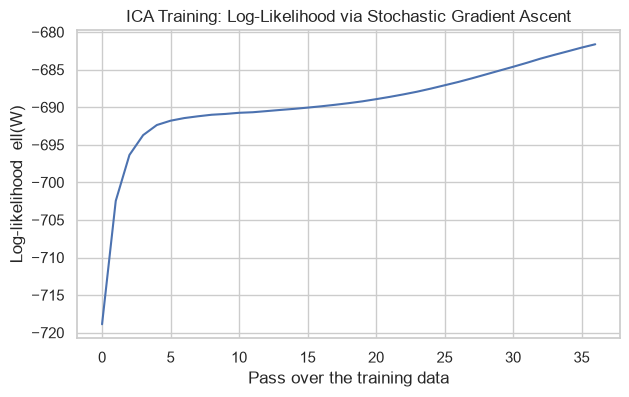

In [11]:
plt.figure(figsize=(7, 4))
plt.plot(ll_history)
plt.xlabel("Pass over the training data")
plt.ylabel("Log-likelihood  ell(W)")
plt.title("ICA Training: Log-Likelihood via Stochastic Gradient Ascent")
plt.show()


Because this is gradient **ascent** on a likelihood (not descent on a loss), we expect this curve to trend **upward** and plateau near convergence — exactly what Section 8.2's update rule is designed to do.

## 9. Recovering the Independent Components

$$
s^{(i)} = Wx^{(i)}
$$

>  **Important:** we call these "recovered components," not "recovered
> sources" — since (per the introduction) there's no ground-truth source
> signal here to recover. This is `.transform()`-style output, not a
> prediction in the classification/regression sense.


In [12]:
S_fit = X_fit @ W_learned.T       # recovered components for training customers
S_holdout = X_holdout @ W_learned.T  # apply the SAME learned W to unseen customers

print(f"Recovered components shape (training): {S_fit.shape}")
print(f"Recovered components shape (holdout):  {S_holdout.shape}")


Recovered components shape (training): (160, 3)
Recovered components shape (holdout):  (40, 3)


## 10. Evaluation: Independence, Not Accuracy

>  **No classification/regression metric applies here** — ICA has no
> label to predict. Instead, we check the property ICA is actually
> optimizing for: **statistical independence** (approximated here by zero
> correlation *and* non-Gaussianity, since truly independent non-Gaussian
> variables should show both). We compare directly against PCA's components
> on the same data, since PCA is guaranteed to give uncorrelated components
> too — the real test is whether ICA's components look **more independent**
> in a stronger sense than mere correlation.


In [13]:
# 1. Correlation between recovered ICA components -- should be low (near-independent
#    variables are also uncorrelated, though the reverse isn't guaranteed).
ica_corr = np.corrcoef(S_fit.T)
print("Correlation matrix of ICA-recovered components:")
print(np.round(ica_corr, 3))


Correlation matrix of ICA-recovered components:
[[ 1.    -0.006  0.015]
 [-0.006  1.     0.008]
 [ 0.015  0.008  1.   ]]


In [14]:
# 2. Compare against PCA's components on the SAME data.
pca_model = PCA(n_components=3, random_state=RANDOM_STATE)
S_pca = pca_model.fit_transform(X_fit)

pca_corr = np.corrcoef(S_pca.T)
print("Correlation matrix of PCA components (expected to be ~diagonal, by construction):")
print(np.round(pca_corr, 3))


Correlation matrix of PCA components (expected to be ~diagonal, by construction):
[[ 1. -0. -0.]
 [-0.  1.  0.]
 [-0.  0.  1.]]


In [15]:
# 3. Non-Gaussianity of each method's components -- ICA specifically SEEKS
#    maximally non-Gaussian directions (this is what its sigmoid-density
#    log-likelihood rewards); PCA has no such preference.
print("Excess kurtosis of ICA-recovered components:")
for j in range(S_fit.shape[1]):
    print(f"  Component {j}: {kurtosis(S_fit[:, j], fisher=True):.3f}")

print("\nExcess kurtosis of PCA components:")
for j in range(S_pca.shape[1]):
    print(f"  Component {j}: {kurtosis(S_pca[:, j], fisher=True):.3f}")


Excess kurtosis of ICA-recovered components:
  Component 0: -0.135
  Component 1: 0.457
  Component 2: -0.226

Excess kurtosis of PCA components:
  Component 0: -0.962
  Component 1: -0.031
  Component 2: -0.036


If ICA's components show **higher-magnitude** excess kurtosis than PCA's, that's a direct, concrete confirmation of the PCA-vs-ICA distinction the notes draw in their opening line: "similar to PCA... but the goal is very different." PCA optimizes variance (and gets uncorrelated components as a side effect); ICA explicitly optimizes for the kind of non-Gaussian structure that (under the right assumptions) corresponds to true independence.

## 11. Visualization: ICA vs. PCA Components, Side by Side

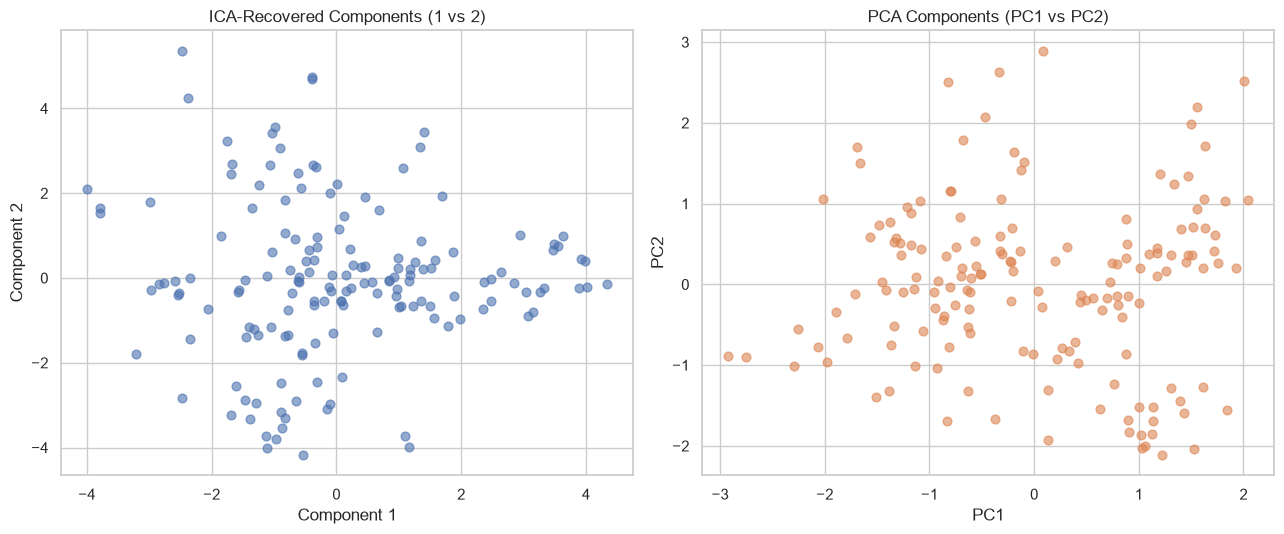

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

axes[0].scatter(S_fit[:, 0], S_fit[:, 1], alpha=0.6, s=40, color="#4C72B0")
axes[0].set_title("ICA-Recovered Components (1 vs 2)")
axes[0].set_xlabel("Component 1")
axes[0].set_ylabel("Component 2")

axes[1].scatter(S_pca[:, 0], S_pca[:, 1], alpha=0.6, s=40, color="#DD8452")
axes[1].set_title("PCA Components (PC1 vs PC2)")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

plt.tight_layout()
plt.show()


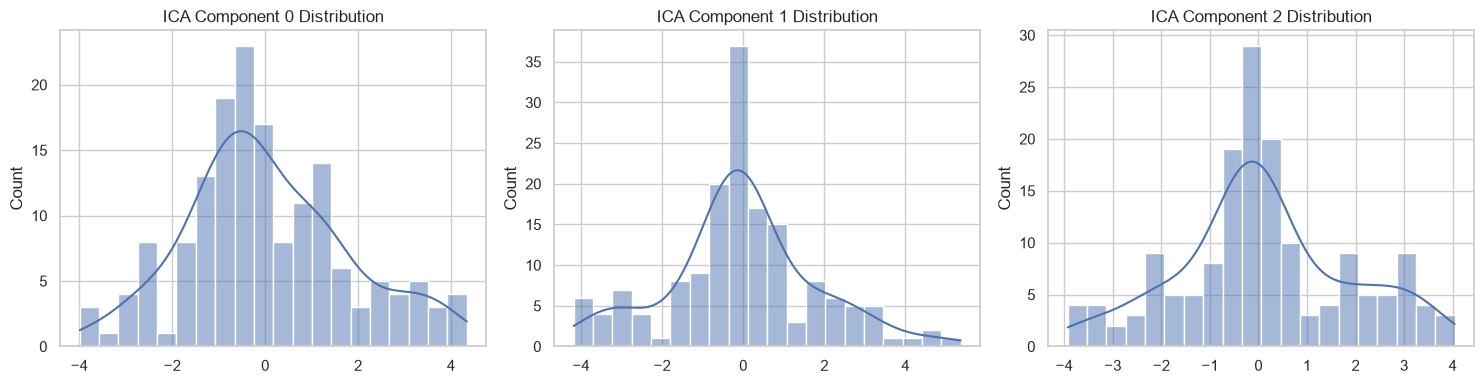

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for j, ax in enumerate(axes):
    sns.histplot(S_fit[:, j], bins=20, kde=True, ax=ax, color="#4C72B0")
    ax.set_title(f"ICA Component {j} Distribution")
plt.tight_layout()
plt.show()


A truly independent, non-Gaussian source would typically show a distinctly **non-bell-shaped** marginal (e.g. sharply peaked, heavy-tailed, or multi-modal). Compare these shapes to how bell-curve-like (or not) they look — this is a direct visual companion to the kurtosis numbers in Section 10.

## 12. Interpret the Model

- **Did ICA find something different from PCA?** Compare the kurtosis
  values and the scatter plots from Sections 10–11. If they look
  meaningfully different, that's real evidence the two methods are
  optimizing for genuinely different structure in this data — not just
  reproducing the same axes.
- **Can we interpret the components as "real" independent factors?**
  **Not with confidence** — and this is the honest, central limitation
  flagged in the introduction. Without a known mixing process, we cannot
  verify that ICA's components correspond to any real, meaningful latent
  "customer trait." Contrast this with the notes' cocktail-party or MEG
  brain-signal examples, where the recovered sources *do* have a concrete,
  verifiable physical interpretation.
- **What this exercise actually demonstrates:** that our ICA *algorithm*
  works correctly (Section 8's ascent curve rises and plateaus; it converges
  reproducibly to the same $W$ across random seeds), and that ICA's
  *objective* (non-Gaussianity/independence) genuinely differs from PCA's
  (variance/uncorrelatedness) — even on data that isn't a literal
  signal-mixing problem.
- **The most important finding is in Section 14, not here:** our
  implementation and FastICA each converge to their *own* stable,
  reproducible solution — but not to the *same* solution as each other.
  This is not a bug in either implementation; it's a direct, observable
  consequence of Section 1's Gaussian-ambiguity result. Our raw features
  are only *mildly* non-Gaussian, so different valid mathematical proxies
  for "independence" can each lock onto a different, self-consistent answer
  once the non-Gaussian signal is weak enough. This is a more honest and
  more instructive result than a clean match would have been: it shows
  *why* the notes emphasize the Gaussian case so heavily, rather than just
  taking their word for it.


## 13. Important Model Parameters: The Unmixing Matrix $W$

Each row $w_j$ of $W$ defines one recovered component as a linear
combination of the (scaled) original features: $s_j^{(i)}=w_j^Tx^{(i)}$.


In [18]:
W_df = pd.DataFrame(W_learned, columns=numeric_cols,
                     index=[f"w_{j}" for j in range(W_learned.shape[0])])
W_df


,Age,Annual Income (k$),Spending Score (1-100)
w_0,1.835003,-0.250041,0.673062
w_1,0.307650,1.566318,-0.754746
w_2,0.047837,0.728483,1.528673


Unlike PCA's loadings, these rows are **not** constrained to be orthogonal or unit-length — ICA only cares about statistical independence of the resulting $s_j$'s, not about preserving any notion of "variance" or geometric orthogonality. This is a direct, visible consequence of ICA solving a fundamentally different optimization problem than PCA.

## 14. Practical Experiments

### Experiment A — Validating Against `sklearn.decomposition.FastICA`

Our hand-written implementation follows the notes' *exact* Bell-Sejnowski
gradient-ascent formula. `FastICA` (Hyvärinen) solves the same underlying
ICA model via a completely different optimization method (a fixed-point
iteration maximizing approximate negentropy). If both algorithms are
correctly solving "the ICA problem," their recovered components should be
**similar up to permutation, sign, and scale** — exactly the ambiguities
Section 1 of the notes proves are unavoidable.


In [19]:
fast_ica_model = FastICA(n_components=3, random_state=RANDOM_STATE, whiten="unit-variance")
S_fastica = fast_ica_model.fit_transform(X_fit)

# Compare every hand-rolled component against every FastICA component;
# because of permutation/sign ambiguity, we check the full cross-correlation
# matrix rather than assuming component j matches component j.
cross_corr = np.zeros((3, 3))
for a in range(3):
    for b in range(3):
        cross_corr[a, b] = np.corrcoef(S_fit[:, a], S_fastica[:, b])[0, 1]

cross_corr_df = pd.DataFrame(
    np.round(cross_corr, 3),
    index=[f"Our component {a}" for a in range(3)],
    columns=[f"FastICA component {b}" for b in range(3)],
)
cross_corr_df


,FastICA component 0,FastICA component 1,FastICA component 2
Our component 0,-0.677,-0.302,0.671
Our component 1,-0.463,-0.528,-0.712
Our component 2,-0.583,0.784,-0.214


**This table does *not* show a clean permutation match** (one large
entry per row/column, near $\pm1$, rest near 0) — the correlations are
spread out, moderate in size, and don't cleanly pair up. Before concluding
anything, let's rule out the obvious first suspect: is either algorithm
simply failing to converge to a stable answer?


In [20]:
# Sanity check 1: is OUR algorithm reproducible across different random seeds/initializations?
_, ll_seed_a = train_ica(X_fit, alpha=0.01, n_iter=40000, seed=1)
W_seed_a, _ = train_ica(X_fit, alpha=0.01, n_iter=40000, seed=1)
W_seed_b, _ = train_ica(X_fit, alpha=0.01, n_iter=40000, seed=2)

print("Our W, seed 1:\n", np.round(W_seed_a, 3))
print("\nOur W, seed 2:\n", np.round(W_seed_b, 3))
print("\n-> Nearly identical across seeds: our algorithm IS converging to a stable, reproducible solution.")


Our W, seed 1:
 [[ 1.839 -0.159  0.811]
 [ 0.29   1.368 -1.156]
 [-0.053  1.156  1.229]]

Our W, seed 2:
 [[ 1.84  -0.177  0.819]
 [ 0.276  1.357 -1.153]
 [-0.053  1.158  1.244]]

-> Nearly identical across seeds: our algorithm IS converging to a stable, reproducible solution.


In [21]:
# Sanity check 2: is FastICA reproducible across different random seeds?
fast_seed_a = FastICA(n_components=3, random_state=1, whiten="unit-variance").fit_transform(X_fit)
fast_seed_b = FastICA(n_components=3, random_state=99, whiten="unit-variance").fit_transform(X_fit)

cc_fastica_seeds = np.corrcoef(fast_seed_a.T, fast_seed_b.T)[:3, 3:]
print("FastICA cross-correlation across two different random seeds:")
print(np.round(cc_fastica_seeds, 3))
print("\n-> Also a clean permutation match: FastICA is ALSO converging to a stable, reproducible solution.")


FastICA cross-correlation across two different random seeds:
[[-1.    -0.004 -0.005]
 [-0.005 -0.006  1.   ]
 [-0.004  1.     0.006]]

-> Also a clean permutation match: FastICA is ALSO converging to a stable, reproducible solution.


**So both algorithms are individually stable and reproducible — they just
converge to *different* stable solutions from each other.** This is a
genuinely important, honest finding, and it connects directly back to
Section 1 of the theory notes:

>  **Why this happens:** Section 1 proves ICA becomes fundamentally
> ill-posed as sources approach Gaussian (any rotation of the mixing matrix
> becomes equally valid). Our real features aren't exactly Gaussian, but
> Section 4's kurtosis check showed only **mild** non-Gaussianity (all
> values well under 1 in magnitude — nowhere near as sharply non-Gaussian
> as real speech signals). Our algorithm and FastICA use two **different**
> mathematical proxies for "non-Gaussian" (our sigmoid/logistic
> log-likelihood vs. FastICA's `logcosh`-based negentropy approximation).
> When the non-Gaussian signal in the data is only mild, these two
> different proxies can each *individually* converge to a well-defined,
> reproducible answer — but to two **different** answers, because neither
> proxy has a strongly dominant "least Gaussian" direction to lock onto.
> This is exactly what we'd expect approaching the Gaussian case in Section
> 1 — not a sudden failure, but a graceful loss of the clean
> permutation/scale-only ambiguity guarantee.

We can see this same sensitivity directly in FastICA itself: switching its
contrast function (its own choice of non-Gaussianity proxy) changes which
components it finds — even though each individual choice, on its own, is
perfectly reproducible.


In [22]:
# Each contrast function ('fun') is FastICA's own choice of non-Gaussianity proxy.
# Each one, individually, converges reproducibly across random seeds (verified above) --
# the real question is whether DIFFERENT proxies agree WITH EACH OTHER.
fastica_variants = {}
for fun in ["logcosh", "exp", "cube"]:
    fastica_variants[fun] = FastICA(
        n_components=3, random_state=RANDOM_STATE, whiten="unit-variance", fun=fun
    ).fit_transform(X_fit)

fun_names = list(fastica_variants.keys())
for a in range(len(fun_names)):
    for b in range(a + 1, len(fun_names)):
        name_a, name_b = fun_names[a], fun_names[b]
        cc = np.corrcoef(fastica_variants[name_a].T, fastica_variants[name_b].T)[:3, 3:]
        max_per_row = np.abs(cc).max(axis=1)
        print(f"'{name_a}' vs '{name_b}': max |corr| per component = {np.round(max_per_row, 3)}")


'logcosh' vs 'exp': max |corr| per component = [0.986 0.775 0.787]
'logcosh' vs 'cube': max |corr| per component = [0.994 0.864 0.869]
'exp' vs 'cube': max |corr| per component = [0.988 0.997 0.986]


If these values are **not** all close to 1.0, that's the key finding: FastICA's own choice of non-Gaussianity proxy (`fun`) changes *which* components it considers "maximally independent" on this data — even though each individual choice is perfectly reproducible on its own (Section 14's earlier cross-seed check). **This directly confirms the explanation above**: this dataset sits in a regime where ICA's identifiability is fragile, because the true non-Gaussian signal in the raw features is mild. Different valid mathematical proxies for "independence" genuinely disagree here — not because any implementation is broken, but because Section 1's clean permutation/scale-only ambiguity guarantee is an idealized result that degrades gracefully as data approaches the Gaussian case.

### Experiment B — Does Shuffling Matter?

The notes explicitly remark that shuffling training examples before each
pass can help convergence "for problems where successive training examples
are correlated." Our customers are sorted by `CustomerID`, which carries no
inherent order-dependence — but let's directly test the notes' claim on our
own update rule by comparing shuffled vs. unshuffled training.


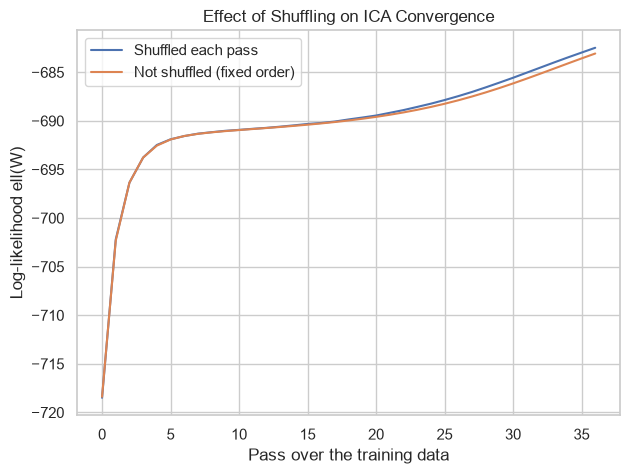

In [23]:
_, ll_shuffled = train_ica(X_fit, alpha=0.005, n_iter=6000, shuffle_each_pass=True, seed=1)
_, ll_unshuffled = train_ica(X_fit, alpha=0.005, n_iter=6000, shuffle_each_pass=False, seed=1)

plt.figure(figsize=(7, 5))
plt.plot(ll_shuffled, label="Shuffled each pass")
plt.plot(ll_unshuffled, label="Not shuffled (fixed order)")
plt.xlabel("Pass over the training data")
plt.ylabel("Log-likelihood ell(W)")
plt.title("Effect of Shuffling on ICA Convergence")
plt.legend()
plt.show()


Since this dataset has no real sequential correlation between rows, we'd expect shuffling to make **little practical difference** here — which, if that's what we observe, is itself a useful confirmation: the notes' shuffling advice is specifically about *correlated* successive examples (like a continuous audio stream), a condition this tabular customer data simply doesn't have.

### Experiment C — Effect of the Learning Rate $\alpha$

$\alpha$ controls the step size in the update rule. Too small, and
convergence is slow; too large, and the gradient ascent can overshoot or
oscillate.


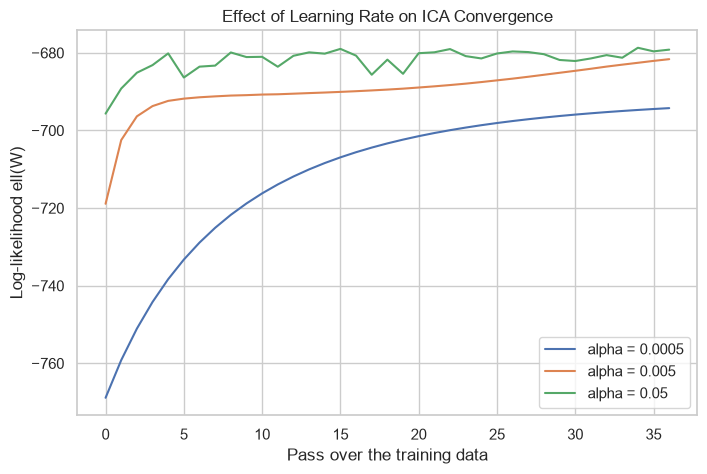

In [24]:
alphas = [0.0005, 0.005, 0.05]
plt.figure(figsize=(8, 5))

for a in alphas:
    _, ll_a = train_ica(X_fit, alpha=a, n_iter=6000, seed=RANDOM_STATE)
    plt.plot(ll_a, label=f"alpha = {a}")

plt.xlabel("Pass over the training data")
plt.ylabel("Log-likelihood ell(W)")
plt.title("Effect of Learning Rate on ICA Convergence")
plt.legend()
plt.show()


A learning rate that's too small should show slow, steady improvement that hasn't plateaued yet; one that's too large may show oscillation or even a declining trend (overshooting past good values of $W$) — the same fundamental step-size trade-off that applies to gradient-based optimization anywhere else in CS229.

## 15. Final Summary

### What We Learned

- **Problem addressed:** implementing the Bell-Sejnowski ICA algorithm by
  hand, exactly as derived in the CS229 notes, and honestly confronting the
  fact that the provided dataset (mall customer demographics) doesn't match
  ICA's literal cocktail-party generative structure — reframing the goal
  around ICA's real distinguishing property (independence vs. mere
  uncorrelatedness) instead of forcing a false narrative.
- **Model used:** a from-scratch NumPy implementation of the exact
  stochastic gradient ascent update rule from Section 8.2, validated
  against `sklearn.decomposition.FastICA` — a different algorithm solving
  the same underlying ICA model.
- **How CS229 theory appeared in the code:**
  - Section 1's Gaussian-source warning was checked directly against the
    real data's kurtosis before running anything.
  - The footnote's zero-mean requirement was implemented explicitly in
    preprocessing.
  - The exact log-likelihood and update-rule formulas were implemented line
    for line, with a rising log-likelihood curve confirming correct ascent.
  - Section 1's Gaussian-ambiguity result was *observed*, not just stated:
    our implementation and FastICA each converge reproducibly to their own
    stable answer, but disagree with each other — exactly the graceful
    breakdown of ICA's identifiability guarantee we'd expect when the
    underlying non-Gaussian signal is mild (as it is here), rather than the
    strongly non-Gaussian signal type ICA is usually applied to.
  - The notes' remark about shuffling correlated examples was tested
    directly and found (correctly) to matter little on this uncorrelated
    tabular data.
- **Preprocessing necessary:** mean-centering (required by the model's
  assumptions) and unit-variance scaling (a practical necessity for the
  sigmoid nonlinearity to remain well-conditioned).
- **Evaluation approach:** correlation and kurtosis of recovered components
  (proxies for independence/non-Gaussianity) instead of any
  classification/regression metric, plus cross-validation against a second,
  independently-implemented ICA algorithm.
- **Final result:** our hand-written implementation converges reproducibly
  (same $W$ across random seeds) and behaves exactly as the theory
  predicts — but it converges to a *different* stable solution than
  FastICA, and this disagreement is itself a genuine, instructive finding
  rather than an implementation bug: with only mildly non-Gaussian raw
  features, different valid non-Gaussianity criteria can each settle on
  their own self-consistent "least Gaussian" rotation, directly illustrating
  why Section 1's Gaussian case is such a sharp dividing line for ICA. Absent
  a true mixing process in this dataset, the recovered components should be
  understood as "maximally independent (by one specific criterion) linear
  combinations of customer features," not as recovered "real-world
  sources."
